## 1. Importing Required Libraries
 for data analysis and visualization.

- **Pandas** → Data manipulation and analysis
- **NumPy** → Numerical computations
- **Matplotlib** → Data visualization
- **Seaborn** → Statistical visualization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset
The dataset is stored inside the `data/raw` folder.
We use Pandas to read the CSV file and store it in a DataFrame named `df`.

In [ ]:
df=pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape of the Dataset

In [ ]:
print("Dataset shape:",df.shape)

Dataset shape: (7043, 21)


In [ ]:
print("columns Name:",df.columns.tolist())

columns Name: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
print("Data types:",df.dtypes)

Data types: customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


## 4. Checking Missing Values

Missing values can affect data analysis and machine learning models. We check the number of missing values present in each column.

In [ ]:
Missing_values=df.isnull().sum()
print(Missing_values[Missing_values>0])

Series([], dtype: int64)


## 5. Checking Duplicate Records

Duplicate customer records can introduce bias into analysis and model training. Therefore, we check whether duplicate rows exist in the dataset.

In [ ]:
duplicates=df.duplicated().sum()
print("number of duplicated records:",duplicates)

number of duplicated records: 0


## 6. Statistical Summary

We use descriptive statistics to understand the numerical features of the customer churn dataset, including their mean, standard deviation, minimum, maximum, and quartile values.

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 7. Churn Distribution

Churn is the target variable of our project. We visualize the number of customers who stayed with the company and those who left.

This helps us understand the distribution of the target variable and identify whether there is a class imbalance.

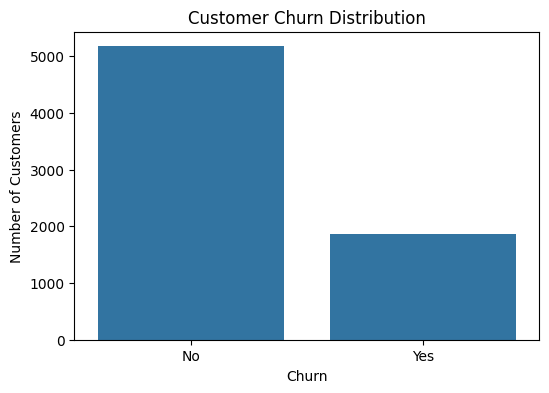

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Churn percentage

In [ ]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 9. Churn Distribution by Gender

We compare customer churn across different genders to determine whether churn behavior differs significantly between male and female customers.

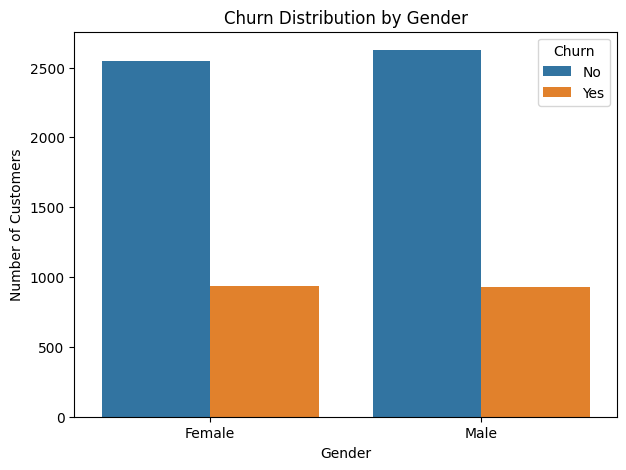

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Churn Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

## 10. Churn Distribution by Contract Type

Contract type may have an important relationship with customer churn.

We visualize churn across different contract categories to identify whether customers with different contract durations show different churn behavior.

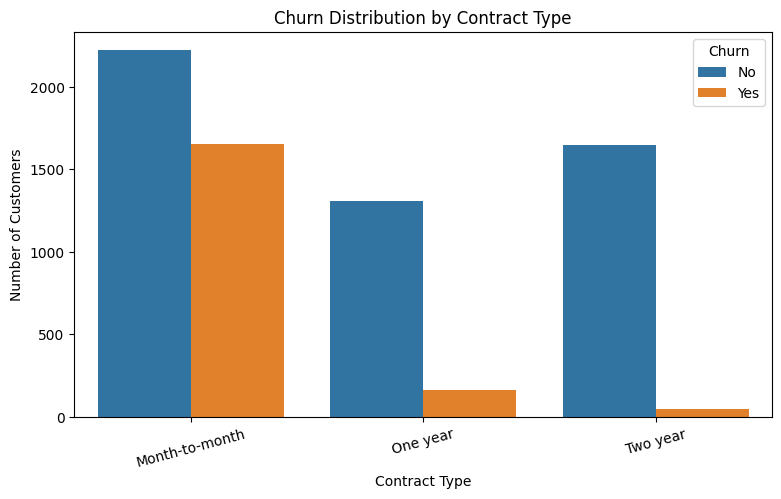

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

## 11. Churn Rate by Contract Type

The number of customers in each contract category is different, so comparing only raw counts can be misleading.

We calculate the churn percentage within each contract type to better understand customer churn behavior.

In [ ]:
contract_churn=pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


Visualization

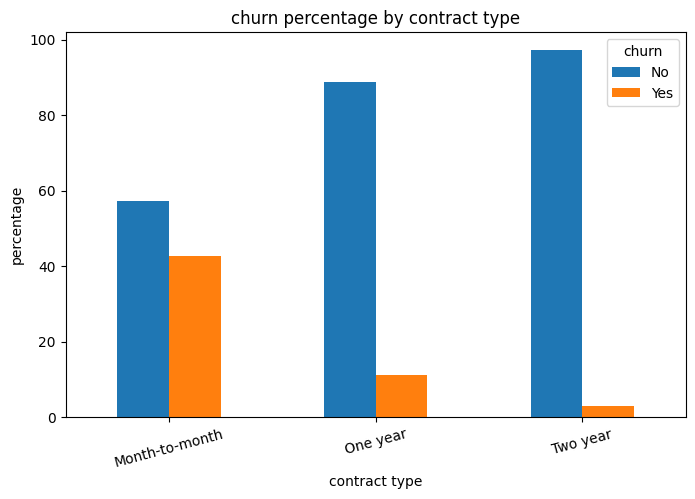

In [ ]:
contract_churn.plot(
    kind="bar",
    figsize=(8,5)

)
plt.title("churn percentage by contract type")
plt.xlabel("contract type")
plt.ylabel("percentage")
plt.xticks(rotation=15)
plt.legend(title="churn")
plt.show()

## 12. Churn Distribution by Internet Service

Internet service type may influence customer churn. We compare churn across different internet service categories.

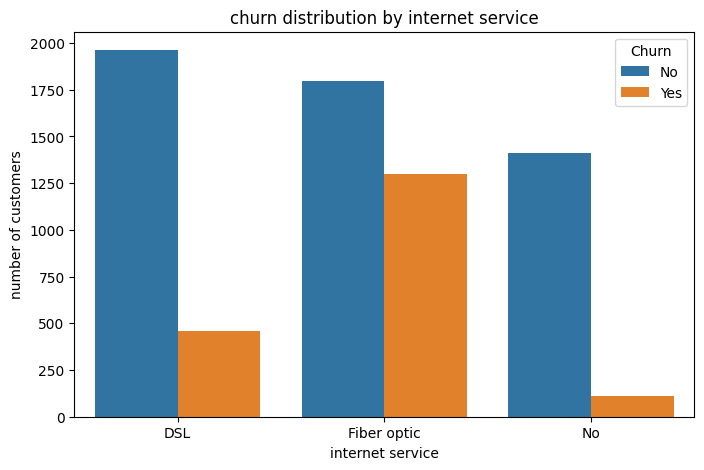

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"

)
plt.title("churn distribution by internet service")
plt.xlabel("internet service")
plt.ylabel("number of customers")
plt.show()

## 13. Churn Distribution by Payment Method

Payment method can provide useful insights into customer behavior and retention. We compare churn across different payment methods.

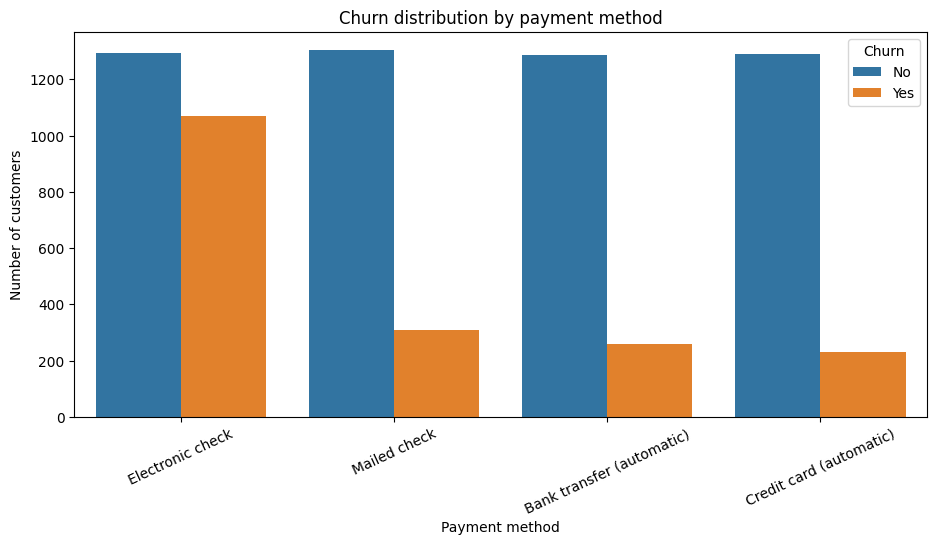

In [ ]:
plt.figure(figsize=(11,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)
plt.title("Churn distribution by payment method")
plt.xlabel("Payment method")
plt.ylabel("Number of customers")
plt.xticks(rotation=25)
plt.show()

## 14. Tenure Distribution by Churn

Tenure represents the number of months a customer has stayed with the company.

We compare tenure distributions between customers who churned and those who stayed to identify whether customer loyalty is related to churn.

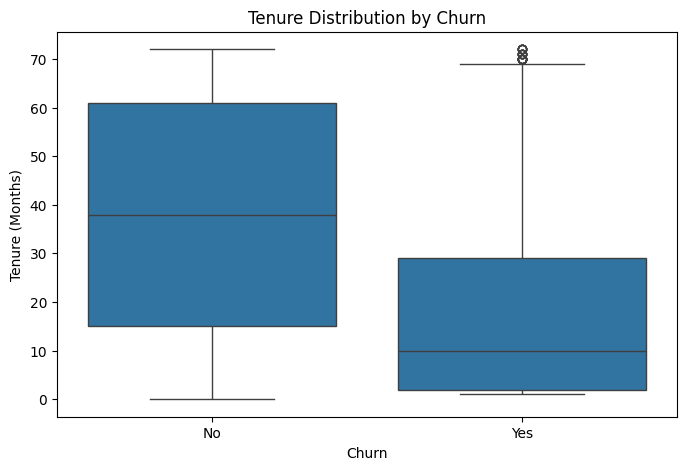

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

## 15. Monthly Charges Distribution by Churn

Monthly charges represent the amount paid by customers each month.

We compare monthly charges between churned and retained customers to investigate whether higher monthly charges are associated with customer churn.

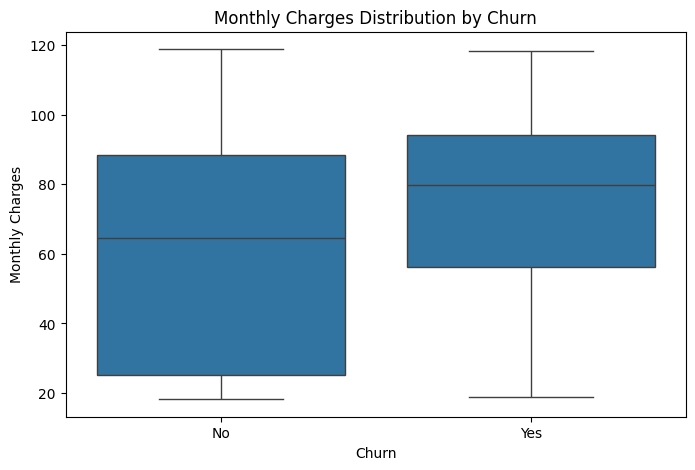

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
print(df["TotalCharges"].dtype)

object


In [ ]:
df["TotalCharges"]=pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
print(df["TotalCharges"].isnull().sum())

11


## 16. Total Charges Distribution by Churn

Total charges represent the total amount paid by a customer during their relationship with the company.

We compare total charges across churn categories to understand whether customer lifetime spending is associated with churn.

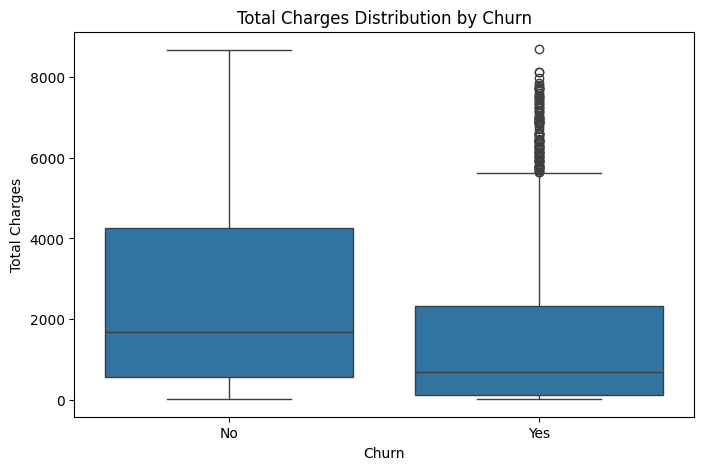

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

## 17. Churn Distribution by Online Security

Online security services may influence customer retention. We compare churn across customers with and without online security services.

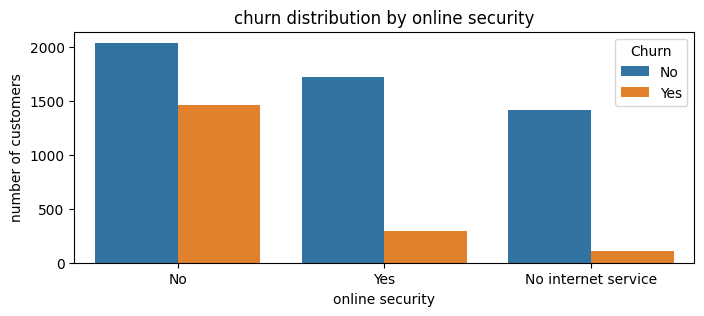

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)
plt.title("churn distribution by online security")
plt.xlabel("online security")
plt.ylabel("number of customers")
plt.show()

## 18. Churn Distribution by Tech Support

Technical support availability may affect customer satisfaction and retention.

We compare churn across different technical support categories.

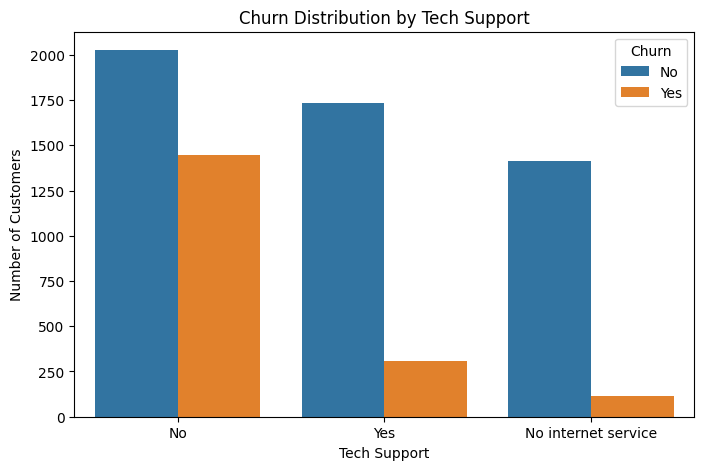

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Churn Distribution by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

## 19. Churn Distribution by Senior Citizen Status

We compare customer churn between senior citizens and non-senior citizens to investigate whether age-related customer characteristics are associated with churn.

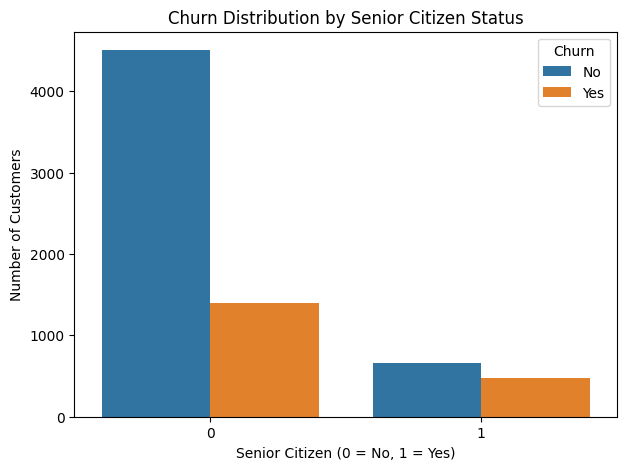

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Churn Distribution by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

## 20. Churn Rate by Categorical Features

Instead of comparing only customer counts, we calculate the churn rate within each category. This provides a more meaningful comparison because different categories may contain different numbers of customers.

In [ ]:
features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport"
]

for feature in features:
    churn_rate = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100

    print(f"\n--- {feature} ---")
    print(churn_rate.round(2))


--- Contract ---
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83

--- InternetService ---
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

--- PaymentMethod ---
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11

--- OnlineSecurity ---
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61

--- TechSupport ---
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


## 21. Correlation Analysis

Correlation analysis helps us understand the linear relationship between numerical features.

A positive correlation means two variables tend to increase together, while a negative correlation means one tends to decrease as the other increases.

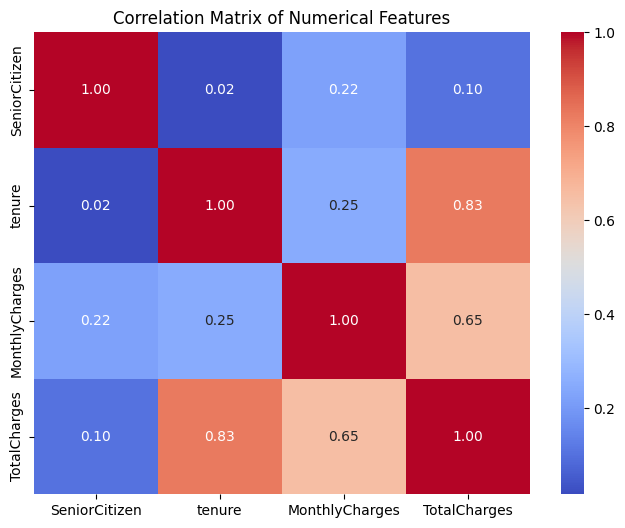

In [ ]:
plt.figure(figsize=(8, 6))

numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

## 22. EDA Insights

Based on the exploratory data analysis, the following observations were identified:

- The dataset contains 7,043 customer records and 21 features.
- Approximately 26.5% of customers have churned, indicating some class imbalance.
- Month-to-month contract customers show a noticeably higher churn rate compared with one-year and two-year contract customers.
- Internet service type shows differences in customer churn behavior.
- Payment method also shows variation in churn rates across customer groups.
- Customers with shorter tenure may have a higher likelihood of churn.
- Monthly charges show differences between churned and retained customers.
- Online security and technical support services may be associated with customer retention.
- Senior citizen status shows differences in churn behavior between the two groups.
- Numerical feature distributions and correlations provide additional information for feature selection and model preparation.

These insights will guide the data preprocessing and feature engineering steps before model training.

## 23. Checking Missing Values After Data Conversion

After converting TotalCharges into a numerical data type, we check for missing values again.

In [ ]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## 24. Handling Missing Total Charges

Missing TotalCharges values correspond to customers with zero tenure. Since these customers have just joined the service, their total charges can reasonably be considered zero.

In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

## 25. Encoding the Target Variable

The target variable Churn is categorical, containing Yes and No values.

We convert it into binary numerical values:

- No → 0
- Yes → 1

In [ ]:
df["Churn"]=df["Churn"].map({
    "No":0,
    "Yes":1

})

In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## 26. Separating Features and Target

We separate the input features from the target variable. The model will use the customer features to predict whether a customer will churn.

In [ ]:
y=df["Churn"]

In [ ]:
X=df.drop("Churn",axis=1)

In [ ]:
print("X Shape:",X.shape)
print("y shape:",y.shape)

X Shape: (7043, 20)
y shape: (7043,)


## 27. Removing Customer ID

customerID is a unique identifier and does not contain meaningful information for predicting customer churn. Therefore, it is removed before model training.

In [ ]:
X = X.drop("customerID", axis=1)

print(X.shape)

(7043, 19)


## 28. Identifying Numerical and Categorical Features

We identify numerical and categorical features separately because they require different preprocessing techniques.

In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 29. Building the Preprocessing Pipeline

Numerical and categorical features require different preprocessing techniques.

- Numerical features are standardized using StandardScaler.
- Categorical features are converted into numerical form using OneHotEncoder.

Using ColumnTransformer allows us to apply the appropriate transformation to each type of feature.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 30. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training the model.
- 20% is reserved for evaluating the model on unseen data.

Stratification is used to preserve the proportion of churned and non-churned customers in both sets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


## 31. Fitting the Preprocessor

The preprocessing transformations are fitted only on the training data.

This prevents data leakage, ensuring that information from the test set is not used during model training.

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (5634, 45)
Processed X_test shape: (1409, 45)


In [ ]:
preprocessor.fit_transform(X_test)

array([[-0.43246516,  1.63495753,  1.67163008, ...,  1.        ,
         0.        ,  0.        ],
       [ 2.31232499, -0.9754628 ,  1.20655549, ...,  1.        ,
         0.        ,  0.        ],
       [-0.43246516,  0.37053518,  0.47715792, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.43246516, -1.09782626, -1.45340352, ...,  0.        ,
         0.        ,  0.        ],
       [-0.43246516,  0.98235244, -1.4851892 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.43246516,  1.63495753,  0.21283495, ...,  0.        ,
         0.        ,  0.        ]], shape=(1409, 45))

## 32. Logistic Regression Baseline Model

Logistic Regression is used as our baseline classification model.

The model learns the relationship between customer characteristics and the probability of churn.

Since Churn is a binary target (0 = No, 1 = Yes), Logistic Regression is a suitable first model.

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression(
    max_iter=1000,
    random_state=42    
)
log_reg.fit(X_train_processed,y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
y_pred = log_reg.predict(X_test_processed)

print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.604


## 35. Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.

It helps us understand whether the model is correctly identifying customers who churn and customers who stay.

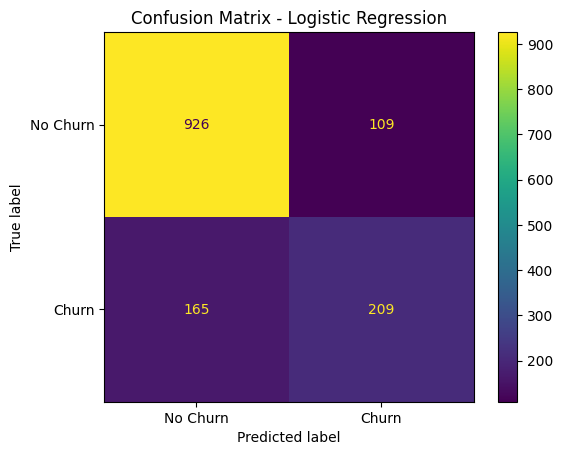

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 36. Decision Tree Classifier

A Decision Tree is a supervised learning algorithm that makes predictions by splitting the data into smaller groups using feature-based decisions.

We train a Decision Tree as a second model and compare its performance with Logistic Regression.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train_processed, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [ ]:
y_pred_dt = dt_model.predict(X_test_processed)

print(y_pred_dt[:20])

[0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


## 38. Evaluating the Decision Tree

We evaluate the Decision Tree using accuracy, precision, recall, and F1-score and compare these metrics with the Logistic Regression baseline.

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))

Decision Tree Results
--------------------
Accuracy : 0.7984
Precision: 0.6347
Recall   : 0.5668
F1 Score : 0.5989


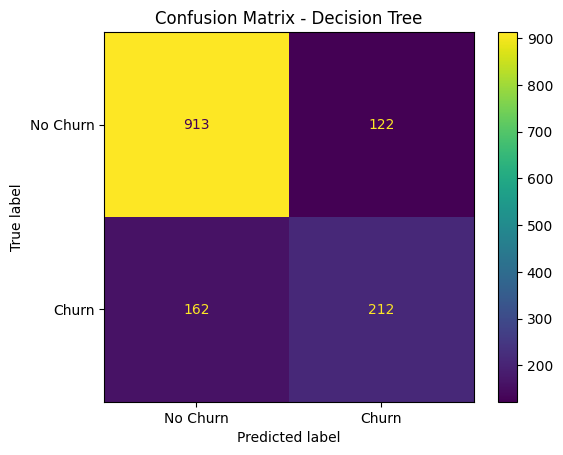

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()

## 40. Model Performance Comparison

We compare the performance of Logistic Regression and Decision Tree using multiple classification metrics.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt
    ],
    "Precision": [
        precision,
        precision_dt
    ],
    "Recall": [
        recall,
        recall_dt
    ],
    "F1 Score": [
        f1,
        f1_dt
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Decision Tree,0.798439,0.634731,0.566845,0.598870


## 41. Model Performance Visualization

A visual comparison makes it easier to understand the relative performance of different models across evaluation metrics.

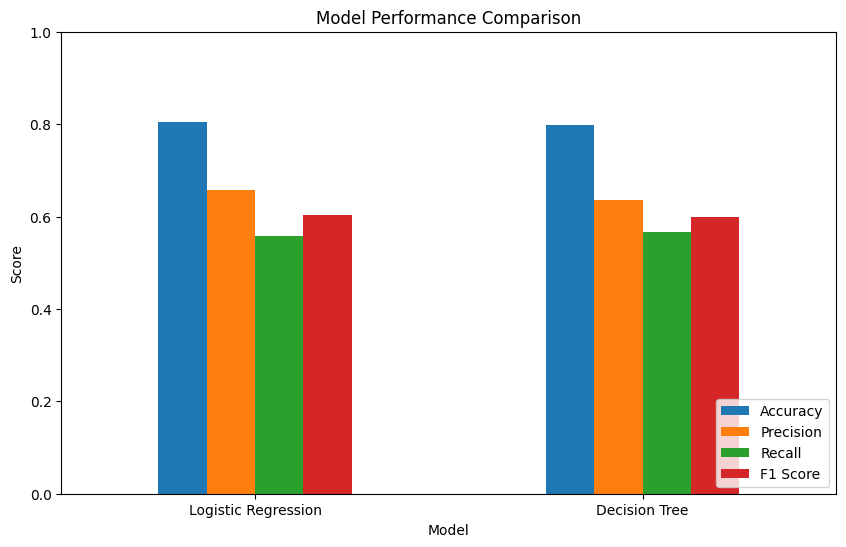

In [ ]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.show()

## 42. Checking Class Distribution

Before handling class imbalance, we inspect the distribution of the target classes in the training data.

The churn dataset contains more non-churn customers than churned customers, so the classes are imbalanced.

In [ ]:
print(y_train.value_counts())

print("\nClass Percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Churn
0    4139
1    1495
Name: count, dtype: int64

Class Percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


## 43. Handling Class Imbalance with Class Weights

The Churn class is the minority class. We use class_weight="balanced" so that the Logistic Regression model gives greater importance to the minority class during training.

This may improve the model's ability to identify customers who are likely to churn.

In [ ]:
log_reg_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg_balanced.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [ ]:
y_pred_balanced = log_reg_balanced.predict(X_test_processed)

accuracy_bal = accuracy_score(y_test, y_pred_balanced)
precision_bal = precision_score(y_test, y_pred_balanced)
recall_bal = recall_score(y_test, y_pred_balanced)
f1_bal = f1_score(y_test, y_pred_balanced)

print("Balanced Logistic Regression")
print("----------------------------")
print("Accuracy :", round(accuracy_bal, 4))
print("Precision:", round(precision_bal, 4))
print("Recall   :", round(recall_bal, 4))
print("F1 Score :", round(f1_bal, 4))

Balanced Logistic Regression
----------------------------
Accuracy : 0.7381
Precision: 0.5043
Recall   : 0.7834
F1 Score : 0.6136


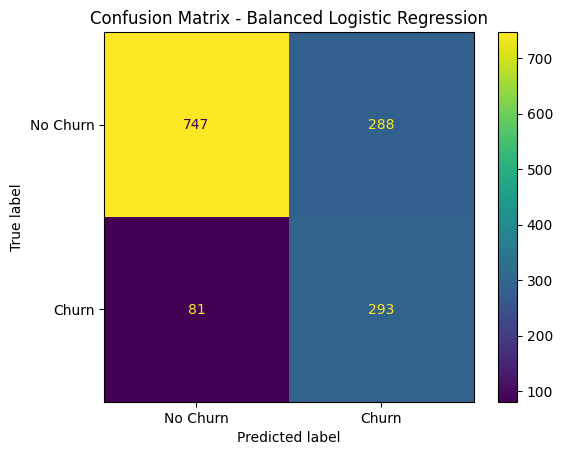

In [ ]:
cm_bal = confusion_matrix(y_test, y_pred_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bal,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

## 46. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees.

Each tree makes a prediction, and the Random Forest combines the predictions of the trees to produce the final result.

Random Forest can capture non-linear relationships and is often effective for structured tabular datasets.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [ ]:
y_pred_rf = rf_model.predict(X_test_processed)

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

Random Forest Results
---------------------
Accuracy : 0.7601
Precision: 0.5333
Recall   : 0.7701
F1 Score : 0.6302


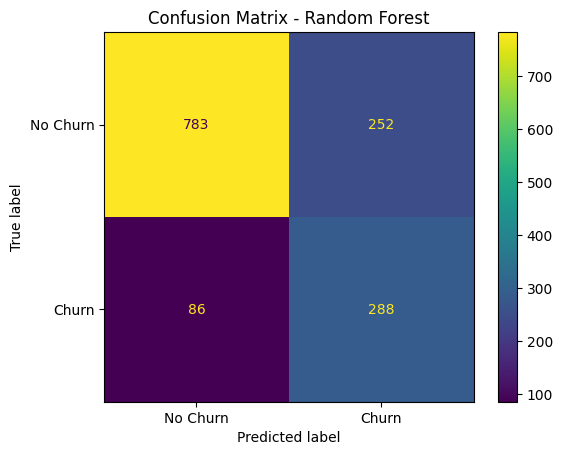

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

## 50. Comparing All Classification Models

We compare all trained models using accuracy, precision, recall, and F1-score to determine which model is most suitable for customer churn prediction.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_bal,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_bal,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_bal,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_dt,
        f1_bal,
        f1_rf
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040
1,Decision Tree,0.7984,0.6347,0.5668,0.5989
2,Balanced Logistic Regression,0.7381,0.5043,0.7834,0.6136
3,Random Forest,0.7601,0.5333,0.7701,0.6302


Find best model by F1

In [ ]:
best_f1_model = results.loc[
    results["F1 Score"].idxmax()
]

print("Best Model based on F1 Score:")
print(best_f1_model)

Best Model based on F1 Score:
Model        Random Forest
Accuracy          0.760114
Precision         0.533333
Recall            0.770053
F1 Score          0.630197
Name: 3, dtype: object


## 52. ROC-AUC Evaluation

ROC-AUC measures the model's ability to distinguish between churned and non-churned customers across different classification thresholds.

A higher ROC-AUC generally indicates better class discrimination.

In [ ]:
from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(
    y_test,
    log_reg.predict_proba(X_test_processed)[:, 1]
)

auc_bal = roc_auc_score(
    y_test,
    log_reg_balanced.predict_proba(X_test_processed)[:, 1]
)

auc_rf = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test_processed)[:, 1]
)

print("Logistic Regression AUC :", round(auc_lr, 4))
print("Balanced LR AUC         :", round(auc_bal, 4))
print("Random Forest AUC       :", round(auc_rf, 4))

Logistic Regression AUC : 0.8421
Balanced LR AUC         : 0.8416
Random Forest AUC       : 0.8416


Model comparison visualization

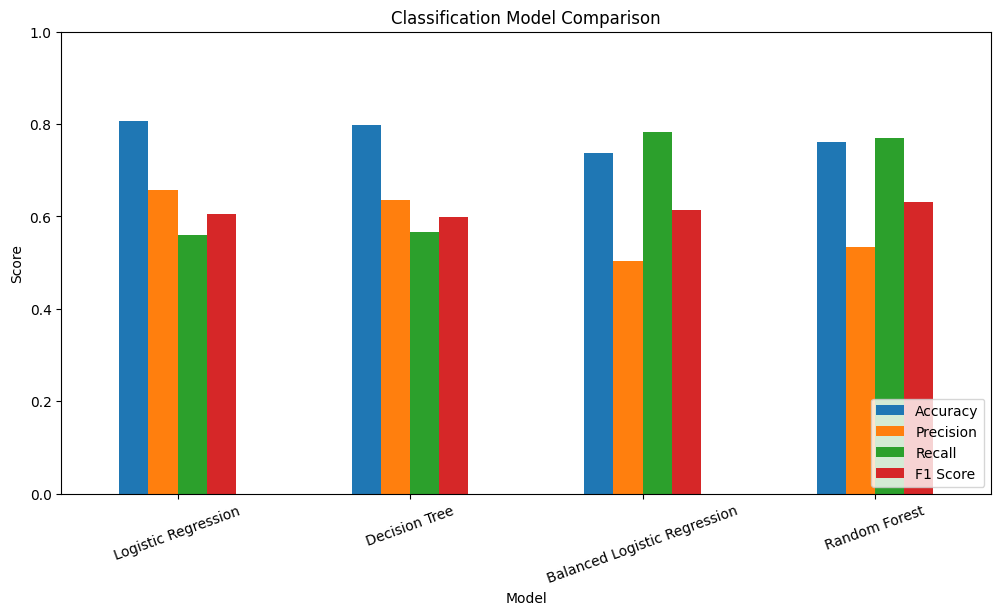

In [ ]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()

## 55. Hyperparameter Tuning

Hyperparameter tuning is used to find better model configurations.

RandomizedSearchCV evaluates randomly selected combinations of hyperparameters using cross-validation and selects the configuration with the best performance according to the chosen scoring metric.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

Create Random forest for tuning

In [ ]:
rf_tuning = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

Run RandomizedSearchCV

In [ ]:
random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
random_search.fit(X_train_processed, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 8}


In [ ]:
print("\nBest CV F1 Score:")
print(round(random_search.best_score_, 4))


Best CV F1 Score:
0.637


In [ ]:
best_rf = random_search.best_estimator_

## 61. Predictions Using the Tuned Random Forest

The best Random Forest configuration obtained through RandomizedSearchCV is evaluated on the unseen test dataset.

In [ ]:
y_pred_tuned = best_rf.predict(X_test_processed)

In [ ]:
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", round(accuracy_tuned, 4))
print("Precision:", round(precision_tuned, 4))
print("Recall   :", round(recall_tuned, 4))
print("F1 Score :", round(f1_tuned, 4))

Tuned Random Forest Results
---------------------------
Accuracy : 0.7523
Precision: 0.5226
Recall   : 0.7727
F1 Score : 0.6235


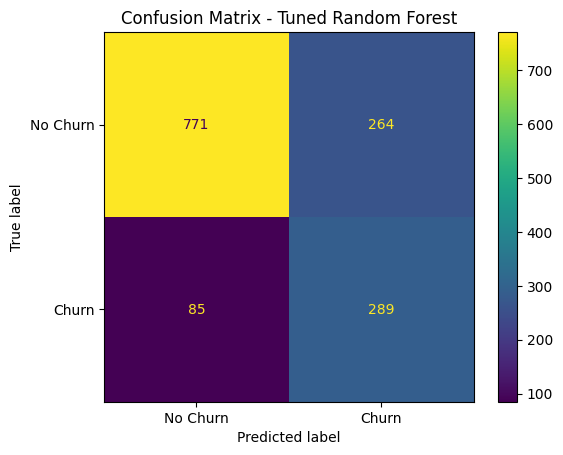

In [ ]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

## 64. Feature Importance Analysis

Feature importance helps us understand which customer characteristics contribute most to the Random Forest's predictions.

This provides useful business insights into the factors associated with customer churn.

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importances = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,num__tenure,0.131762
36,cat__Contract_Month-to-month,0.117371
38,cat__Contract_Two year,0.082638
3,num__TotalCharges,0.082456
18,cat__OnlineSecurity_No,0.058615
16,cat__InternetService_Fiber optic,0.053451
2,num__MonthlyCharges,0.053047
27,cat__TechSupport_No,0.049680
43,cat__PaymentMethod_Electronic check,0.040821
15,cat__InternetService_DSL,0.024230


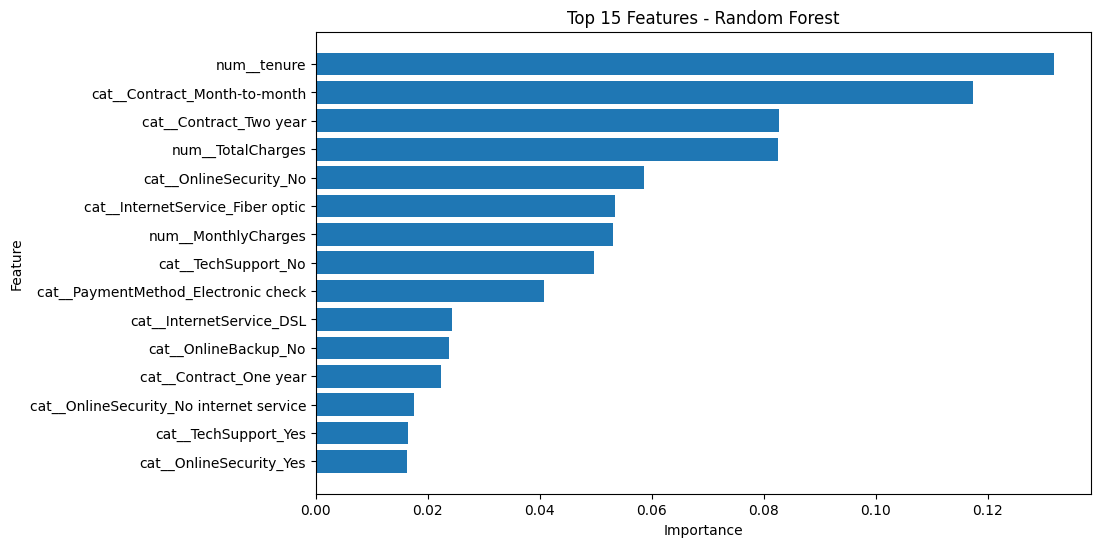

In [ ]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")
plt.show()

## 66. Final Model Selection

After comparing multiple classification models, the tuned Random Forest is selected as the final model.

The selection is based primarily on F1-score and Recall because identifying potential churn customers is an important objective of this project.

## 67. Saving the Final Model

The trained Random Forest model and preprocessing pipeline are saved using joblib.

The preprocessor is also saved because new customer data must undergo the same encoding and transformation used during training.

In [ ]:
import joblib

joblib.dump(best_rf, "../models/churn_random_forest.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [ ]:
loaded_model = joblib.load("../models/churn_random_forest.pkl")
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print("Model loaded successfully!")
print("Preprocessor loaded successfully!")

Model loaded successfully!
Preprocessor loaded successfully!


In [ ]:
y_pred_loaded = loaded_model.predict(X_test_processed)

print(
    "Loaded model predictions match:",
    np.array_equal(y_pred_tuned, y_pred_loaded)
)

Loaded model predictions match: True
